# Alpha Sweep Analysis (eps=0.1, budget=1000, AbsErr Selection)

This notebook analyzes the results of the alpha sweep experiment with **Absolute Error** marginal selection. Synthetic data was generated with `eps=0.1` and marginals were obtained with a high privacy budget (`1000`).

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

sns.set_theme(style="whitegrid")

## 1. Load Data

In [2]:
# Load aggregated data
df = pd.read_csv('../experiments_alpha_eps01_b1000_abserr.csv')

# Pre-processing
df['engine'] = df['meta_synthesizer_params_model_path'].apply(lambda x: 'aim' if 'aim' in str(x).lower() else ('mst' if 'mst' in str(x).lower() else 'patectgan'))
df['alpha'] = df['meta_repairer_params_alpha']

# Map columns to names used in the analysis
column_mapping = {
    'deletion_ratio_ratio': 'deletion_ratio',
    'marginals_error_synthetic_avg': 'marginal_error_syn',
    'marginals_error_repaired_avg': 'marginal_error_rep',
    'tvd_2way_synthetic_avg': 'tvd_syn',
    'tvd_2way_repaired_avg': 'tvd_rep',
    'violations_synthetic': 'violations_syn',
    'violations_repaired': 'violations_rep',
    'runtime_repairing': 'runtime_repairing',
    'marginal_generation_quality_avg_relative_error': 'marginal_gen_error',
    'marginal_selection_quality_precision_at_k': 'marginal_sel_precision',
    'marginal_selection_quality_overlap_count': 'marginal_sel_overlap'
}

for old_col, new_col in column_mapping.items():
    if old_col in df.columns:
        df[new_col] = df[old_col]

# Map ML columns
for col in df.columns:
    if col.startswith('ml_accuracy_synthetic_'):
        df[col.replace('ml_accuracy_synthetic_', 'ml_') + '_syn'] = df[col]
    elif col.startswith('ml_accuracy_repaired_'):
        df[col.replace('ml_accuracy_repaired_', 'ml_') + '_rep'] = df[col]

print(f"Successfully loaded {len(df)} unique experiments.")
df.head()

Successfully loaded 132 unique experiments.


,dataset,experiment_name,experiment_id,timestamp,meta_loader,meta_synthesizer,meta_obtainer,meta_repairer,meta_synthesizer_params_model_path,meta_synthesizer_params_size,...,violations_rep,marginal_gen_error,marginal_sel_precision,marginal_sel_overlap,ml_logistic_regression_syn,ml_random_forest_syn,ml_mlp_syn,ml_logistic_regression_rep,ml_random_forest_rep,ml_mlp_rep
0,adult,alpha_eps01_b1000_abserr_adult_aim_a0.55,327bd14f,2026-05-17T23:29:55.029861,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim_eps0.1.pkl,50000,...,0,0.000103,1.0,20.0,0.806539,0.81864,0.816736,0.813562,0.827423,0.824598
1,adult,alpha_eps01_b1000_abserr_adult_aim_a0.6,fcb28fb0,2026-05-18T03:15:50.888613,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim_eps0.1.pkl,50000,...,0,0.000103,1.0,20.0,0.806539,0.81864,0.816736,0.814361,0.826051,0.828672
2,adult,alpha_eps01_b1000_abserr_adult_aim_a0.75,6fb694c8,2026-05-17T17:38:30.905449,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim_eps0.1.pkl,50000,...,0,0.000103,1.0,20.0,0.806539,0.81864,0.816736,0.810163,0.817268,0.820237
3,adult,alpha_eps01_b1000_abserr_adult_aim_a0.8,25953629,2026-05-17T17:38:34.314172,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim_eps0.1.pkl,50000,...,0,0.000103,1.0,20.0,0.806539,0.81864,0.816736,0.810143,0.818271,0.819541
4,adult,alpha_eps01_b1000_abserr_adult_aim_a0.85,cd21e044,2026-05-17T19:27:05.875513,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim_eps0.1.pkl,50000,...,0,0.000103,1.0,20.0,0.806539,0.81864,0.816736,0.810143,0.817063,0.817596


## 2. Visualisation of Deletion Ratio and TVD Tradeoff

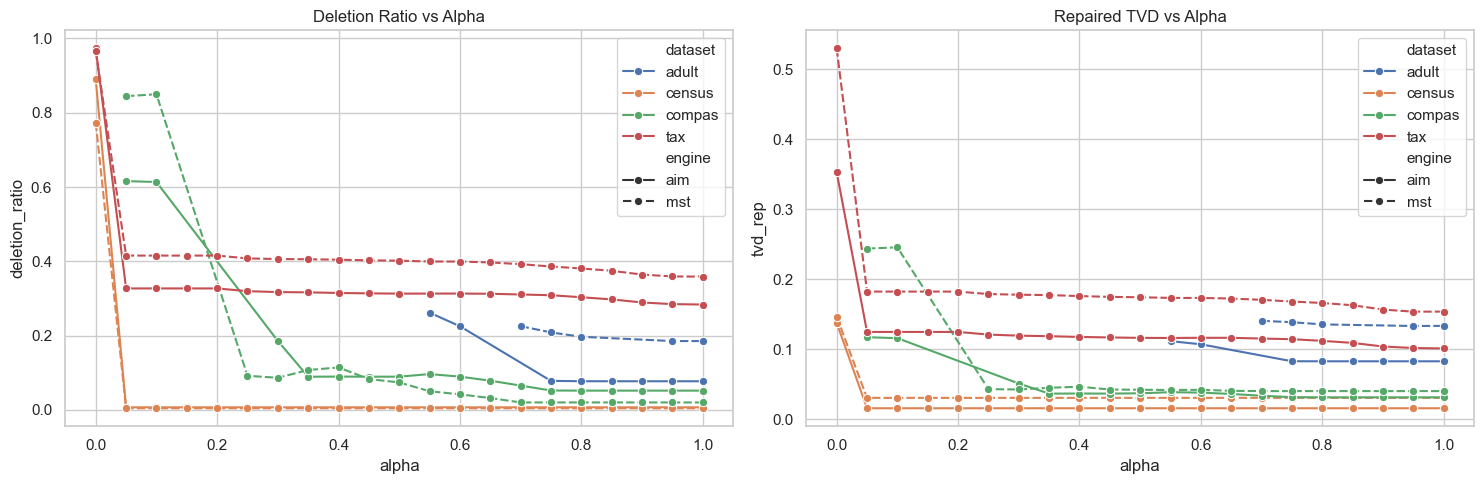

In [3]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    sns.lineplot(data=df, x='alpha', y='deletion_ratio', hue='dataset', style='engine', ax=axes[0], marker='o')
    axes[0].set_title('Deletion Ratio vs Alpha')
    
    sns.lineplot(data=df, x='alpha', y='tvd_rep', hue='dataset', style='engine', ax=axes[1], marker='o')
    axes[1].set_title('Repaired TVD vs Alpha')
    
    plt.tight_layout()
    plt.show()

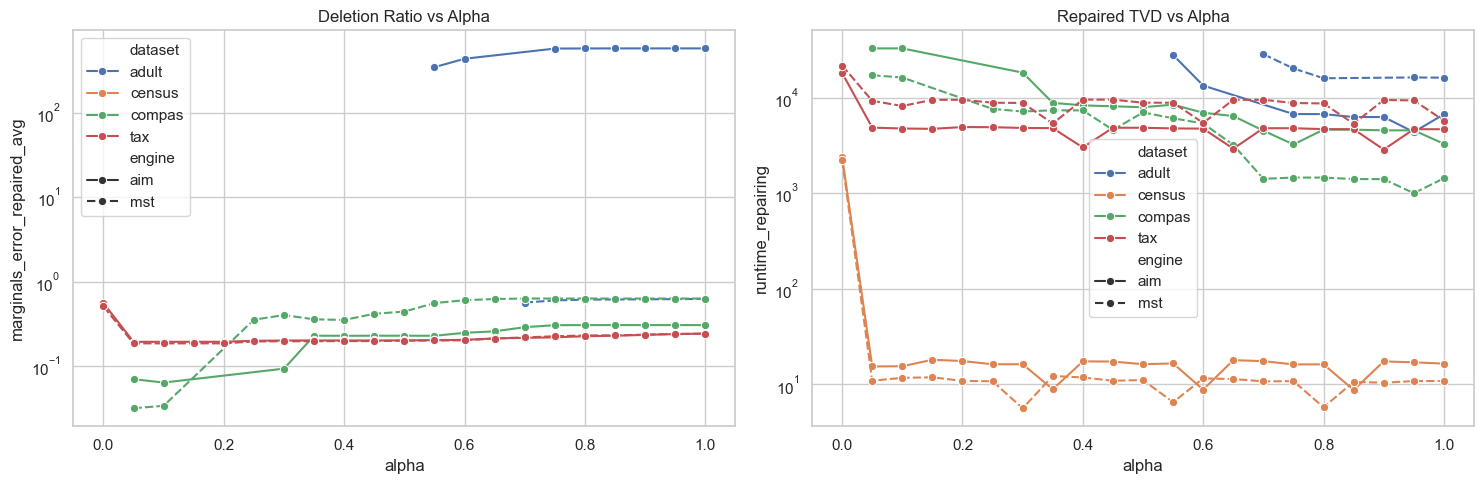

In [ ]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    sns.lineplot(data=df, x='alpha', y='marginals_error_repaired_avg', hue='dataset', style='engine', ax=axes[0], marker='o')
    axes[0].set_title('Marginals Error vs Alpha')
    axes[0].set_yscale('log')
    
    sns.lineplot(data=df, x='alpha', y='runtime_repairing', hue='dataset', style='engine', ax=axes[1], marker='o')
    axes[1].set_title('Runtime vs Alpha')
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.show()